In [ ]:
#Installing libraries
%pip install pandas numpy matplotlib seaborn statsmodels

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Ignore harmless warnings to keep the notebook clean for your presentation
import warnings
warnings.filterwarnings('ignore')

In [4]:
#Data Ingestion & Diagnostic Check

#Load the dataset
file_path = '../data/raw/train.csv' 
df = pd.read_csv(file_path)

#View the first 5 rows
print("--- First 5 Rows ---")
display(df.head())

#Check data types and look for missing values (Nulls)
print("\n--- Data Structure & Missing Values ---")
display(df.info())

#Get a statistical summary of the numerical columns
print("\n--- Statistical Summary ---")
display(df.describe())

--- First 5 Rows ---


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1



--- Data Structure & Missing Values ---
<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB


None


--- Statistical Summary ---


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [5]:
#Convert datetime string to a proper pandas datetime object
df['datetime'] = pd.to_datetime(df['datetime'])
print("Datetime conversion complete. New type:", df['datetime'].dtype)

#Verify missing values
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

#Mathematically detect outliers using the IQR (Interquartile Range) method
print("\n--- Outlier Count (IQR Method) ---")
numerical_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count how many rows fall outside the bounds
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers")

#Checking for hidden missing values in the data
print("--- Total Unique Values Per Column ---")
display(df.nunique())

print("\n--- Deep Dive: Categorical Value Distributions ---")
categorical_cols = ['season', 'holiday', 'workingday', 'weather']

for col in categorical_cols:
    print(f"\nValue Counts for '{col}':")
    # Using dropna=False ensures we still see nulls if they somehow sneaked in
    # sort_index() keeps the categories in numerical order for easier reading
    display(df[col].value_counts(dropna=False).sort_index())

Datetime conversion complete. New type: datetime64[us]

--- Missing Values Count ---
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

--- Outlier Count (IQR Method) ---
temp: 0 outliers
atemp: 0 outliers
humidity: 22 outliers
windspeed: 227 outliers
casual: 749 outliers
registered: 423 outliers
count: 300 outliers
--- Total Unique Values Per Column ---


datetime      10886
season            4
holiday           2
workingday        2
weather           4
temp             49
atemp            60
humidity         89
windspeed        28
casual          309
registered      731
count           822
dtype: int64


--- Deep Dive: Categorical Value Distributions ---

Value Counts for 'season':


season
1    2686
2    2733
3    2733
4    2734
Name: count, dtype: int64


Value Counts for 'holiday':


holiday
0    10575
1      311
Name: count, dtype: int64


Value Counts for 'workingday':


workingday
0    3474
1    7412
Name: count, dtype: int64


Value Counts for 'weather':


weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64

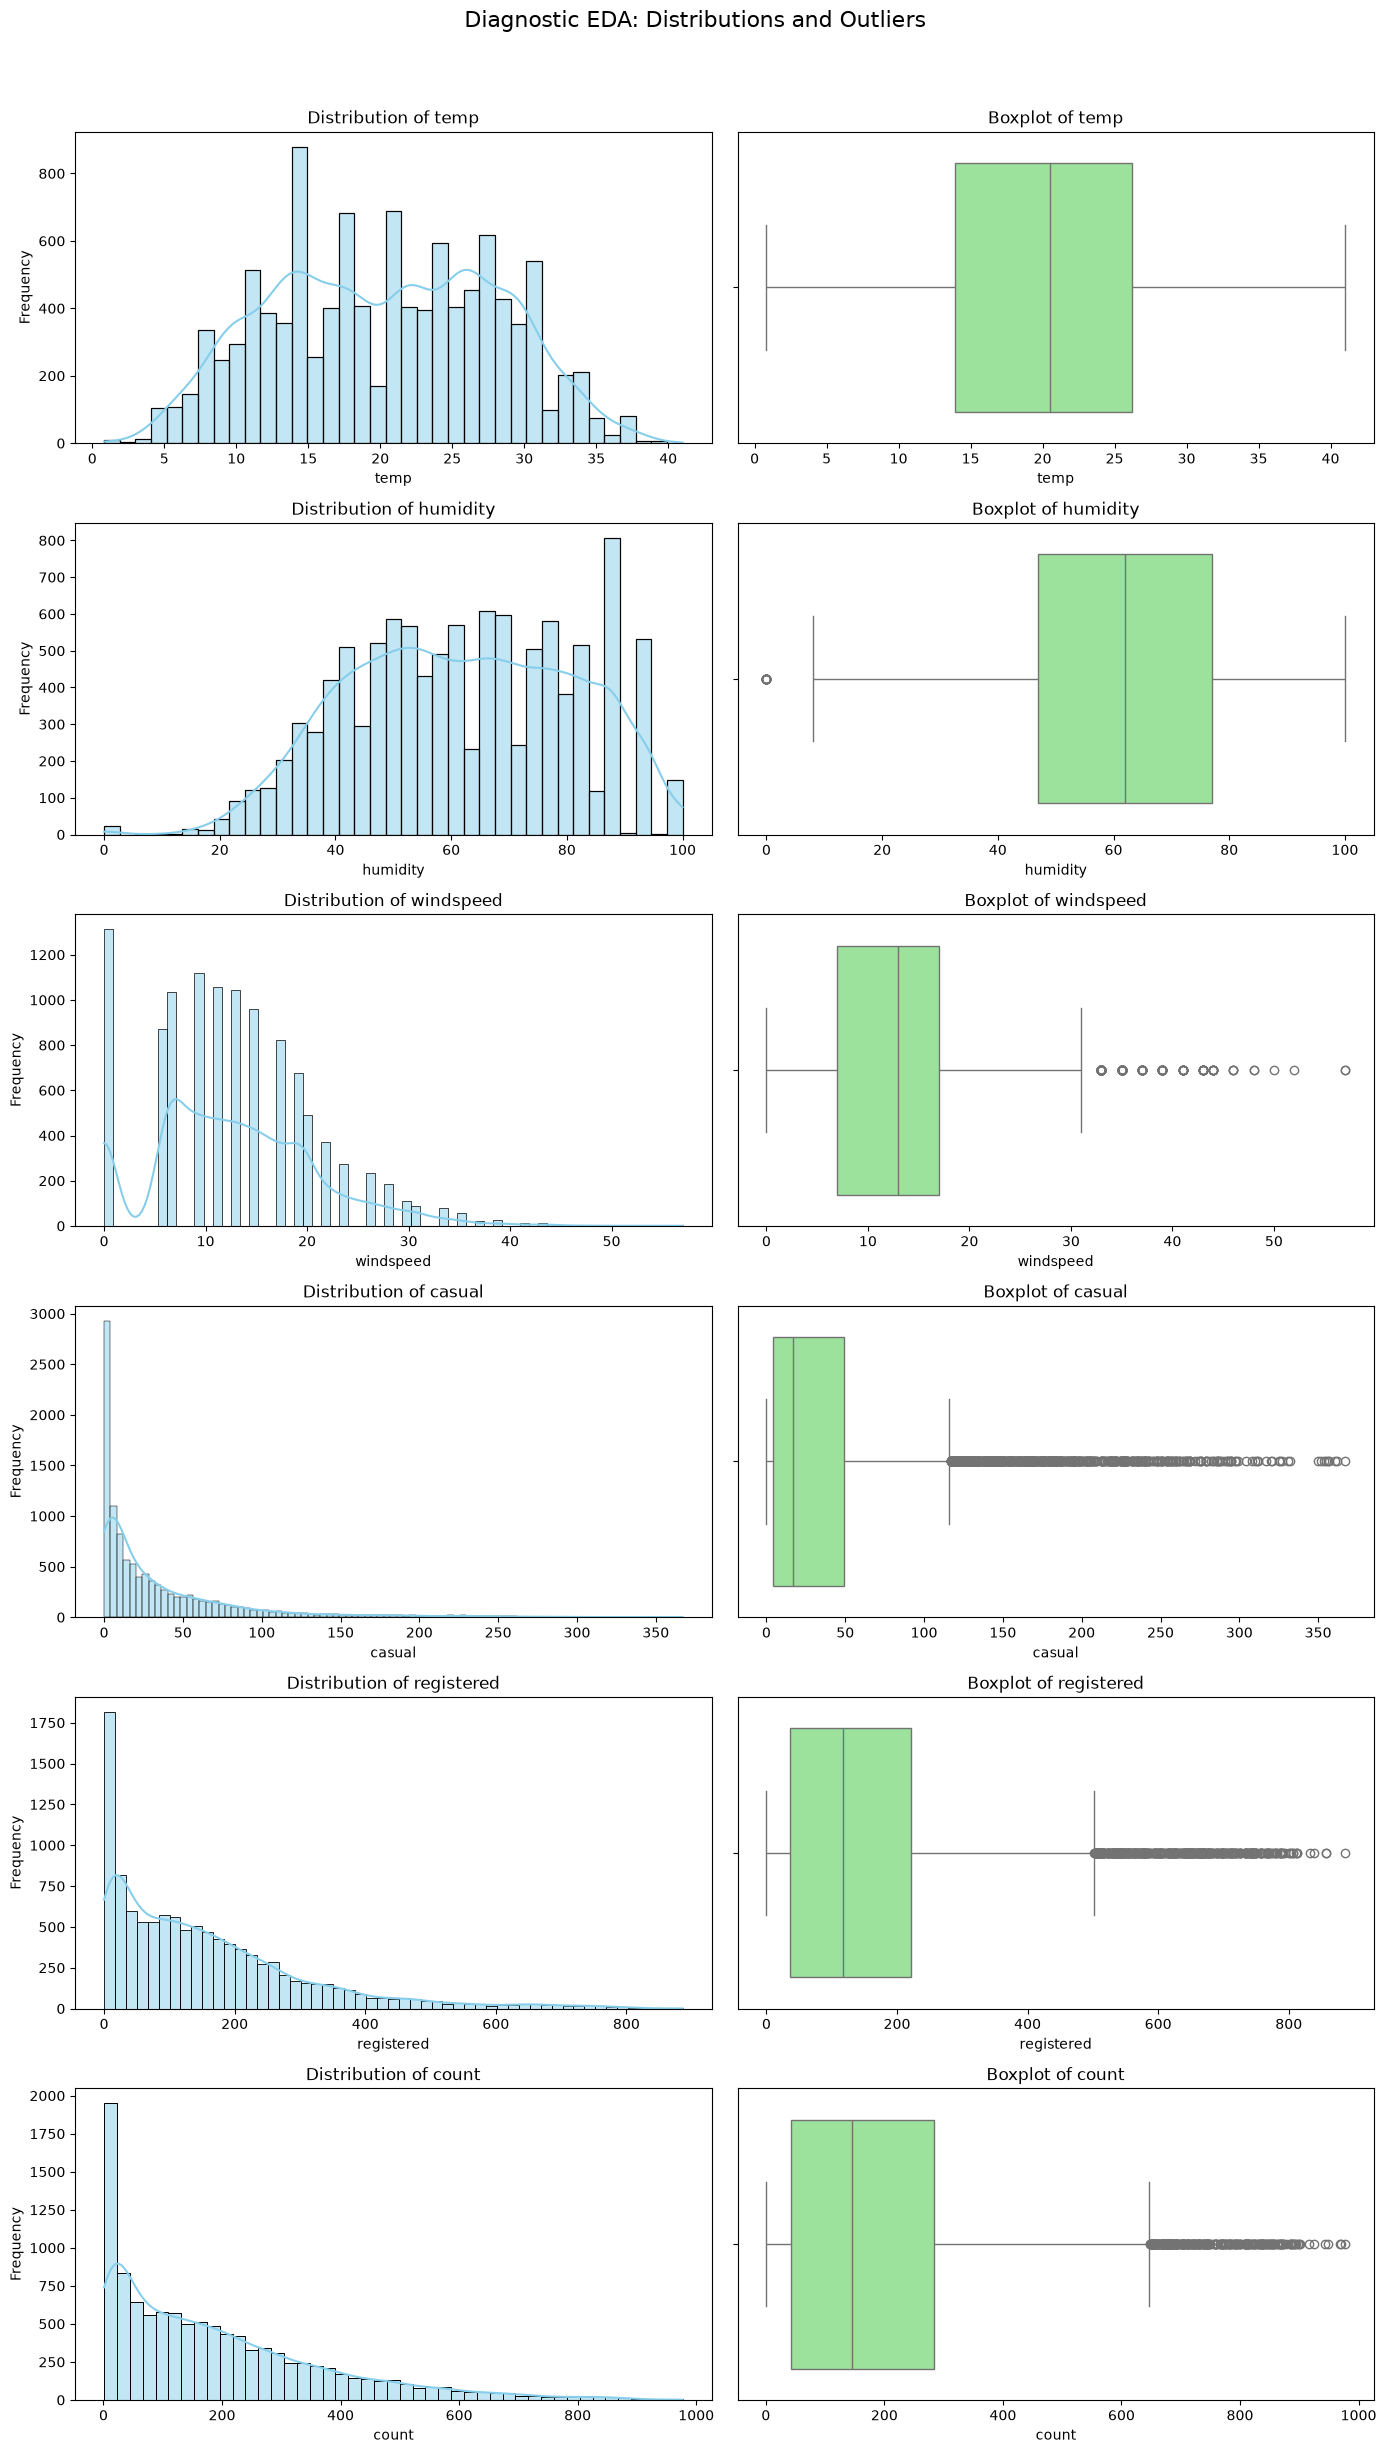

In [6]:
#Visualizing the data distribution to better understand the data

#We will plot histograms and boxplots for our core continuous variables
features_to_plot = ['temp', 'humidity', 'windspeed', 'casual', 'registered', 'count']

#Create a figure with multiple subplots (2 columns: Histogram, Boxplot)
fig, axes = plt.subplots(nrows=len(features_to_plot), ncols=2, figsize=(14, 4 * len(features_to_plot)))
fig.suptitle('Diagnostic EDA: Distributions and Outliers', fontsize=16, y=1.02)

for i, col in enumerate(features_to_plot):
    # Histogram (Left column)
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Distribution of {col}')
    axes[i, 0].set_ylabel('Frequency')
    
    # Boxplot (Right column)
    sns.boxplot(x=df[col], ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'Boxplot of {col}')

# Adjust layout so labels don't overlap
plt.tight_layout()
plt.show()